# 02 · 실제 chunk length–latency와 포화 모델의 검증

기준 $s$는 **측정한 throughput이 관측 최고값의 99%에 처음 도달한 논리적 chunk 길이**다. 이 $s$를 기준으로 측정 곡선이 **affine, 연속 hinge, 포화 이후 원점을 지나는 두 직선** 중 어느 모델을 지지하는지 검증한다. 작은 학습 오차나 throughput 최대점 하나만으로 포화를 선언하지 않는다.

크기는 서브모듈의 논리적 요청 크기 $x$ (**KiB**), latency는 $T(x)$ (**ms/chunk**)로 표시한다. 원래 수식의 4 KiB 행 수 $\ell$과는 $x=4\ell$ 관계다. 1 KiB 간격 측정도 있으므로 $x$를 4 KiB 행 수나 모델 채널 수로 해석하지 않는다. 따라서 $s$의 bit 길이는 $8192s$다. CSV에는 bytes와 bits도 남긴다.

$$\rho(x)=T(x)/x,\qquad B(x)=\frac{1000x}{1024T(x)}\;[\mathrm{MiB/s}],\qquad \arg\min\rho=\arg\max B.$$

이는 단위 변환을 포함한 항등식이다. 유한한 최적 크기, 유일한 포화점, 두 직선 형태의 존재는 별도의 가설이다. 예를 들어 $T=a+bx$에서 $a>0$이면 $\rho=b+a/x$는 계속 감소한다.

## 실행 준비

`runs/02_chunk_latency/`를 지우고 새로 만든다. 아래부터 실행하면 새 실측을 수행한다. 이번 개정은 **실행하지 않았으며**, 이전 프로토콜의 출력은 노트북에서 제거했다. 디스크에 남아 있는 이전 결과는 이 개정의 검증 결과가 아니다.

`preliminary_research/vlm-flash/scripts/profile_flash.py`의 native reader, chunk 수 sweep, throughput 추정 함수를 그대로 사용한다. native reader가 buffered I/O로 대체되면 즉시 중단한다.

In [7]:
from pathlib import Path
from contextlib import redirect_stdout
from io import StringIO
from tempfile import gettempdir
import json
import os
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import nnls
from tqdm.auto import tqdm
from IPython.display import display

ROOT = Path.cwd()
if (ROOT / "conclusion/python").is_dir():
    ROOT = ROOT / "conclusion/python"
sys.path.insert(0, str(ROOT))
import importlib
import reporting
reporting = importlib.reload(reporting)  # Pick up edits in a running Jupyter kernel.
begin, figure, finish = reporting.begin, reporting.figure, reporting.finish
SEED = 0
rng = np.random.default_rng(SEED)
RUN = begin(ROOT, "02_chunk_latency", SEED)
SUBMODULE = ROOT.parents[1] / "preliminary_research/vlm-flash"
sys.path.insert(0, str(SUBMODULE / "src"))
sys.path.insert(0, str(SUBMODULE / "scripts"))
os.environ.setdefault("TORCH_EXTENSIONS_DIR", str(Path(gettempdir()) / "vlmflash-torch-extensions"))
import profile_flash as profiler
from _lock import exclusive

class DirectOnly:
    def __init__(self, extension):
        self.extension = extension

    def read_rows(self, *args, **kwargs):
        result = self.extension.read_rows(*args, **kwargs)
        if not result[3]:
            raise RuntimeError("Native reader did not use O_DIRECT")
        return result

extension = profiler.native()
if extension is None:
    raise RuntimeError(profiler.unavailable_reason())
reader = DirectOnly(extension)

**결과:** `runs/02_chunk_latency/` · seed `0`

## 1. 반복 블록을 갖는 dense sweep

1–256 KiB는 1 KiB 간격, 260–768 KiB는 4 KiB 간격으로 **384개 크기**를 측정한다. 7개 블록마다 크기 순서를 새로 무작위화한다. 각 크기에서 서브모듈의 chunk 수 $q$ schedule을 순서대로 측정하며, 각 $q$마다 warmup 3회와 측정 10회를 수행한다. native worker는 6개다. 이 10회와 7개 전체 반복 블록은 서로 다른 반복 수준이다.

대상 파일시스템에 128 MiB 난수 파일을 새로 쓰고 `fsync`한다. 서브모듈처럼 chunk 사이에 32 KiB 간격을 두며, 파일에 들어가는 $q$만 측정한다. 큰 크기에서는 최대 $q$가 작아지므로 실제 $q$ 범위도 저장한다. `O_DIRECT`는 page cache를 우회하지만 SSD controller cache까지 비우지는 않는다. 1 KiB 논리 요청은 실제 direct I/O 정렬 때문에 더 큰 물리 읽기를 유발할 수 있다.

native 호출의 `max_read_bytes=768 KiB`를 넘으면 요청이 분할되므로 이번 범위는 768 KiB까지다. 경계까지 효율이 개선된다면 포화점은 미확정이며, 범위를 늘리려면 native 분할 조건도 함께 검토해야 한다. 99% 지점에서 데이터를 잘라내지 않는다.

크기별 `done` 출력은 숨기고, 전체 sweep을 **하나의 `tqdm` 진행바**로 표시한다. 원시 시간과 추정값은 블록마다 저장한다.

In [8]:
SIZES_KIB = np.r_[np.arange(1, 257), np.arange(260, 769, 4)].tolist()
BLOCKS, ITERS, WARMUP, THREADS, BLOB_MIB = 7, 10, 3, 6, 128
num_rows = BLOB_MIB * 1024 // profiler.ROW_KB
blob = RUN / "profile_blob.dat"
mount = json.loads(subprocess.check_output(
    ["findmnt", "-T", str(RUN), "-J", "-o", "SOURCE,FSTYPE,TARGET"], text=True
))["filesystems"][0]
if mount["fstype"] in {"tmpfs", "ramfs"}:
    raise RuntimeError("Place the experiment on the target storage filesystem")
hardware = dict(mount=mount, sizes_kib=SIZES_KIB, blocks=BLOCKS, iterations=ITERS,
                warmup=WARMUP, threads=THREADS, blob_mib=BLOB_MIB,
                chunk_counts=profiler.NUM_CHUNKS_SCHED,
                gap_kib=profiler.GAP_ROWS * profiler.ROW_KB, max_native_read_kib=768,
                size_order="randomized within each block", logical_request_bytes=True,
                seed=SEED, blob_seed=0, estimator="profile_flash.saturation_throughput")
(RUN / "hardware.json").write_text(json.dumps(hardware, indent=2))
raw_records, estimates = [], []
with exclusive("02_chunk_latency: native model validation"):
    try:
        profiler.prepare_blob(str(blob), num_rows)
        with tqdm(total=BLOCKS * len(SIZES_KIB), desc="SSD sweep", unit="size", mininterval=1) as bar:
            for block in range(BLOCKS):
                bar.set_postfix(block=f"{block + 1}/{BLOCKS}", refresh=False)
                for order, kib in enumerate(rng.permutation(SIZES_KIB)):
                    kib = int(kib)
                    with redirect_stdout(StringIO()):
                        runs = profiler.measure(reader, str(blob), num_rows, [kib],
                                                ITERS, WARMUP, THREADS)[kib]
                    throughput = profiler.saturation_throughput(runs, kib)
                    estimates.append(dict(block=block, order=order, size_kib=kib,
                        latency_ms=1000 * kib / (1024 * throughput),
                        throughput_mib_s=throughput, count_points=len(runs),
                        max_count=runs[-1][0]))
                    for count, times in runs:
                        raw_records.extend(dict(block=block, order=order, size_kib=kib,
                            size_bytes=kib * 1024, size_bits=kib * 8192, count=count,
                            repeat=i, io_us=float(t)) for i, t in enumerate(times))
                    bar.update()
                pd.DataFrame(raw_records).to_csv(RUN / "io_raw.csv", index=False)
                pd.DataFrame(estimates).to_csv(RUN / "block_estimates.csv", index=False)
    finally:
        blob.unlink(missing_ok=True)
raw = pd.DataFrame(raw_records)
estimates = pd.DataFrame(estimates)
display(pd.Series(hardware))

creating 128 MB blob at /home/yabsed/Documents/fall26/work/graduate-paper/vlm-in-flash/conclusion/python/runs/02_chunk_latency/profile_blob.dat


SSD sweep: 100%|██████████| 2688/2688 [31:42<00:00,  1.41size/s, block=7/7]


mount                    {'source': '/dev/nvme0n1p3[/home]', 'fstype': ...
sizes_kib                [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
blocks                                                                   7
iterations                                                              10
warmup                                                                   3
threads                                                                  6
blob_mib                                                               128
chunk_counts             [1, 2, 4, 8, 16, 28, 32, 48, 64, 96, 128, 192,...
gap_kib                                                                 32
max_native_read_kib                                                    768
size_order                                    randomized within each block
logical_request_bytes                                                 True
seed                                                                     0
blob_seed                

## 2. 무엇을 latency로 추정하는가

각 $(x,q,b)$에서 native reader가 반환한 `io_us`의 10회 median으로 논리적 throughput을 계산한다. 서브모듈의 `saturation_throughput`은 $q$를 늘렸을 때 throughput의 3점 이동평균 기울기가 작아지는 위치 이후의 평균을 선택한다. 해당 위치를 찾지 못해도 마지막 20%의 평균을 반환한다. 따라서 함수 이름만으로 실제 포화를 확인했다고 볼 수 없다.

블록별 추정 throughput $\widehat B_b(x)$로부터
$$\widehat T_b(x)=\frac{1000x}{1024\widehat B_b(x)}$$
를 만든다. 이는 native 병렬 읽기의 **throughput으로 환산한 chunk당 비용**이며 단일 read service time이나 Python 4-worker batch 비용과 같지 않다. 아래에서 실제 chunk 수에 따른 throughput과 마지막 두 $q$ 사이의 변화도 확인한다.

처음 4개 블록 median을 학습값, 마지막 3개 median을 holdout으로 사용한다. 전체 7개 median과 10–90% 범위는 측정 곡선의 요약이다. 그 범위는 신뢰구간이 아니다. 순서를 무작위화해도 동일 SSD의 시간적 drift나 cache 상관이 없어지는 것은 아니다.

In [9]:
wide = estimates.pivot(index="size_kib", columns="block", values="latency_ms").sort_index()
assert wide.shape == (len(SIZES_KIB), BLOCKS) and wide.notna().all().all()
x = wide.index.to_numpy(dtype=float)
samples = wide.to_numpy()
y = np.median(samples, axis=1)
lo, hi = np.quantile(samples, [.1, .9], axis=1)
train = np.median(samples[:, :4], axis=1)
holdout = np.median(samples[:, 4:], axis=1)
ratio = y / x
curve = pd.DataFrame(dict(size_kib=x, median_ms=y, p10_ms=lo, p90_ms=hi,
                          train_ms=train, holdout_ms=holdout, ms_per_kib=ratio))
curve.to_csv(RUN / "latency_curve.csv", index=False)
display(curve)

,size_kib,median_ms,p10_ms,p90_ms,train_ms,holdout_ms,ms_per_kib
0,1.0,0.009635,0.009187,0.010396,0.009484,0.009752,0.009635
1,2.0,0.009294,0.009189,0.010568,0.009911,0.009211,0.004647
2,3.0,0.011130,0.010899,0.011286,0.011054,0.011167,0.003710
3,4.0,0.009101,0.009039,0.009277,0.009185,0.009089,0.002275
4,5.0,0.011492,0.011402,0.011591,0.011505,0.011490,0.002298
...,...,...,...,...,...,...,...
379,752.0,0.135797,0.134028,0.137706,0.135164,0.137302,0.000181
380,756.0,0.133696,0.133416,0.138929,0.135497,0.133492,0.000177
381,760.0,0.135618,0.134264,0.137609,0.135098,0.135963,0.000178
382,764.0,0.135591,0.134562,0.137349,0.136673,0.135381,0.000177


## 3. throughput으로 기준 $s$ 정의

서브모듈 `profile_flash.py`와 같이 크기별 throughput을 **인접한 최대 3점의 median**으로 평활화한다. 평활화된 값의 최고치 $B_{\mathrm{peak}}$에 대해

$$s=\min\{x\in\mathcal G:\widetilde B(x)\ge0.99 B_{\mathrm{peak}}\},\qquad s_{\mathrm{bits}}=8192s_{\mathrm{KiB}}.$$

**처음 기준에 도달한 길이**라는 뜻이다. 이후 모든 크기에서 99% 이상이 유지된다는 뜻은 아니다. 모델 검증의 holdout을 보존하기 위해 $s$는 처음 4개 블록의 median으로 정한다. 전체 7개 블록에서 계산한 값도 진단값으로 표시한다. 측정 상한에서 최고 throughput이 나타나거나 첫 도달점이 상한에 붙으면 포화 위치를 확정할 수 없다. 범위 상한을 임의로 $s$로 대입하지 않는다. 서브모듈은 첫 99% 지점에서 표를 자르지만, 여기서는 그 뒤 곡선까지 측정하여 가설을 검증한다.


s_kib                           256.0
s_bits                        2097152
all_blocks_s_kib                256.0
train_peak_mib_s          5784.457707
all_blocks_peak_mib_s     5816.125526
peak_at_upper_boundary          False
dtype: object

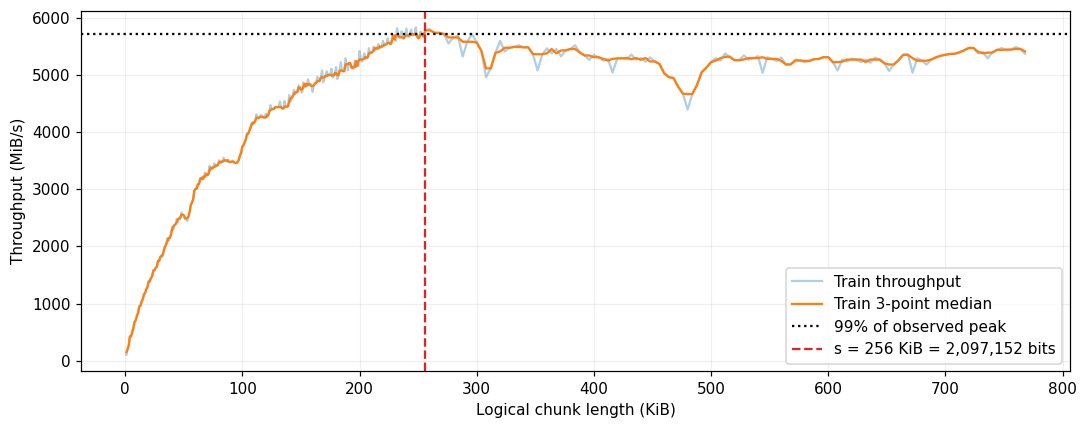

In [10]:
def throughput_threshold(latency_ms):
    throughput = 1000 * x / (1024 * latency_ms)
    smooth = np.array([np.median(throughput[max(0, i - 1):i + 2])
                       for i in range(len(x))])
    peak = smooth.max()
    first = np.flatnonzero(smooth >= .99 * peak)[0]
    return float(x[first]), throughput, smooth, float(peak)

s, train_throughput, train_smooth, train_peak = throughput_threshold(train)
s_all, all_throughput, all_smooth, all_peak = throughput_threshold(y)
throughput_curve = pd.DataFrame(dict(size_kib=x, size_bits=x.astype(int) * 8192,
    train_mib_s=train_throughput, train_smoothed_mib_s=train_smooth,
    all_blocks_mib_s=all_throughput, all_blocks_smoothed_mib_s=all_smooth))
throughput_curve.to_csv(RUN / "throughput_by_length.csv", index=False)
display(pd.Series(dict(s_kib=s, s_bits=int(s * 8192), all_blocks_s_kib=s_all,
                       train_peak_mib_s=train_peak, all_blocks_peak_mib_s=all_peak,
                       peak_at_upper_boundary=bool(x[train_smooth.argmax()] == x[-1]))))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, train_throughput, alpha=.35, label="Train throughput")
ax.plot(x, train_smooth, label="Train 3-point median")
ax.axhline(.99 * train_peak, color="black", ls=":", label="99% of observed peak")
ax.axvline(s, color="tab:red", ls="--", label=f"s = {s:g} KiB = {int(s * 8192):,} bits")
ax.set(xlabel="Logical chunk length (KiB)", ylabel="Throughput (MiB/s)")
ax.legend()
figure(RUN, "throughput_threshold")

## 4. 세 모델을 동일한 학습 자료에 적합

$$\begin{aligned}
T_A(x)&=a+bx,\\
T_H(x)&=a+bx+d(x-s)_+,\\
T_S(x)&=b_1x+d\max(s,x),\qquad b_1,d\ge0.
\end{aligned}$$

Affine와 hinge의 계수는 비제약 최소제곱으로 추정한다. Plateau는 NNLS로 추정한다. Hinge는 연속성만 강제하며, 증가성이나 포화를 보장하지 않는다. 물리적으로 부적절한 음의 예측도 진단 표에 표시한다.

Plateau 모델에서는 $x\le s$일 때 $T_S=ds+b_1x$, $x\ge s$일 때 $T_S=(b_1+d)x$다. 따라서 $\rho_S=b_1+d\max(s/x,1)$이고 **$s$ 이후의 모든 길이가 같은 효율**이다. $s$만 유일한 최적 길이라는 뜻은 아니다. $d=0$이면 breakpoint를 식별할 수 없다. $T_S(0)=0$은 별도 정의이며 적합에는 양의 크기만 쓴다.

Plateau 모델의 $s$는 앞에서 **throughput 99% 기준으로 선택한 값에 고정**한다. Hinge의 breakpoint는 양쪽에 최소 3개의 측정점이 남는 `x[3:-3]`에서 학습 latency의 비가중 MSE로 따로 선택한다. 두 breakpoint의 의미는 다르다. 학습으로 얻은 계수와 breakpoint를 고정한 뒤 holdout RMSE·MAPE를 계산한다. RMSE는 큰 절대 오차의 영향을 많이 받으므로 상대오차도 함께 본다. holdout으로 모델을 비교하므로, 선택된 최종 모델의 성능을 다시 독립 검증한 것은 아니다.

In [11]:
def design(z, kind, s=None):
    if kind == "Affine":
        return np.column_stack([np.ones_like(z), z])
    if kind == "Hinge":
        return np.column_stack([np.ones_like(z), z, np.maximum(z - s, 0)])
    return np.column_stack([z, np.maximum(s, z)])

models, parameters, fit_rows = {}, {}, []
candidates = x[3:-3]
for kind in ["Affine", "Hinge", "Plateau"]:
    best = None
    trial_breaks = [None] if kind == "Affine" else ([s] if kind == "Plateau" else candidates)
    for breakpoint in trial_breaks:
        matrix = design(x, kind, breakpoint)
        coef = nnls(matrix, train)[0] if kind == "Plateau" else np.linalg.lstsq(matrix, train, rcond=None)[0]
        prediction = matrix @ coef
        mse = np.mean((train - prediction) ** 2)
        if best is None or mse < best[0]:
            best = mse, breakpoint, coef, prediction
    mse, breakpoint, coef, prediction = best
    models[kind] = prediction
    parameters[kind] = dict(s_kib=None if breakpoint is None else float(breakpoint), coefficients=coef.tolist())
    fit_rows.append(dict(model=kind, s_kib=breakpoint, train_rmse_us=1000 * np.sqrt(mse),
        holdout_rmse_us=1000 * np.sqrt(np.mean((holdout - prediction) ** 2)),
        holdout_mape_pct=100 * np.mean(np.abs(holdout - prediction) / holdout),
        nonpositive_predictions=int(np.count_nonzero(prediction <= 0)),
        breakpoint_at_search_edge=bool(kind == "Hinge" and breakpoint in (candidates[0], candidates[-1]))))
fits = pd.DataFrame(fit_rows).set_index("model")
fits.to_csv(RUN / "model_comparison.csv")
(RUN / "model_parameters.json").write_text(json.dumps(parameters, indent=2))
display(fits)
display(parameters)

,s_kib,train_rmse_us,holdout_rmse_us,holdout_mape_pct,nonpositive_predictions,breakpoint_at_search_edge
model,,,,,,
Affine,NaN,3.819018,3.816256,10.003809,0,False
Hinge,230.0,2.171401,2.093589,2.918660,0,False
Plateau,256.0,2.495500,2.455749,4.266998,0,False


{'Affine': {'s_kib': None,
  'coefficients': [0.006532970548386405, 0.00017079809938813352]},
 'Hinge': {'s_kib': 230.0,
  'coefficients': [0.012350397279148726,
   0.0001239148280611668,
   6.519697071364594e-05]},
 'Plateau': {'s_kib': 256.0,
  'coefficients': [0.00014063365391609503, 4.260782180355241e-05]}}

### 곡선과 holdout 잔차

왼쪽은 전체 블록의 측정 요약과 **학습 4개 블록으로만 적합한** 모델이다. 짧은 chunk의 형태는 inset으로 확인한다. 오른쪽 잔차는 학습에 사용하지 않은 3개 블록 median − 예측이다. 체계적인 휘어짐이나 크기에 따른 오차 증가는 작은 전체 RMSE에 가려진 모델 부적합의 단서다.

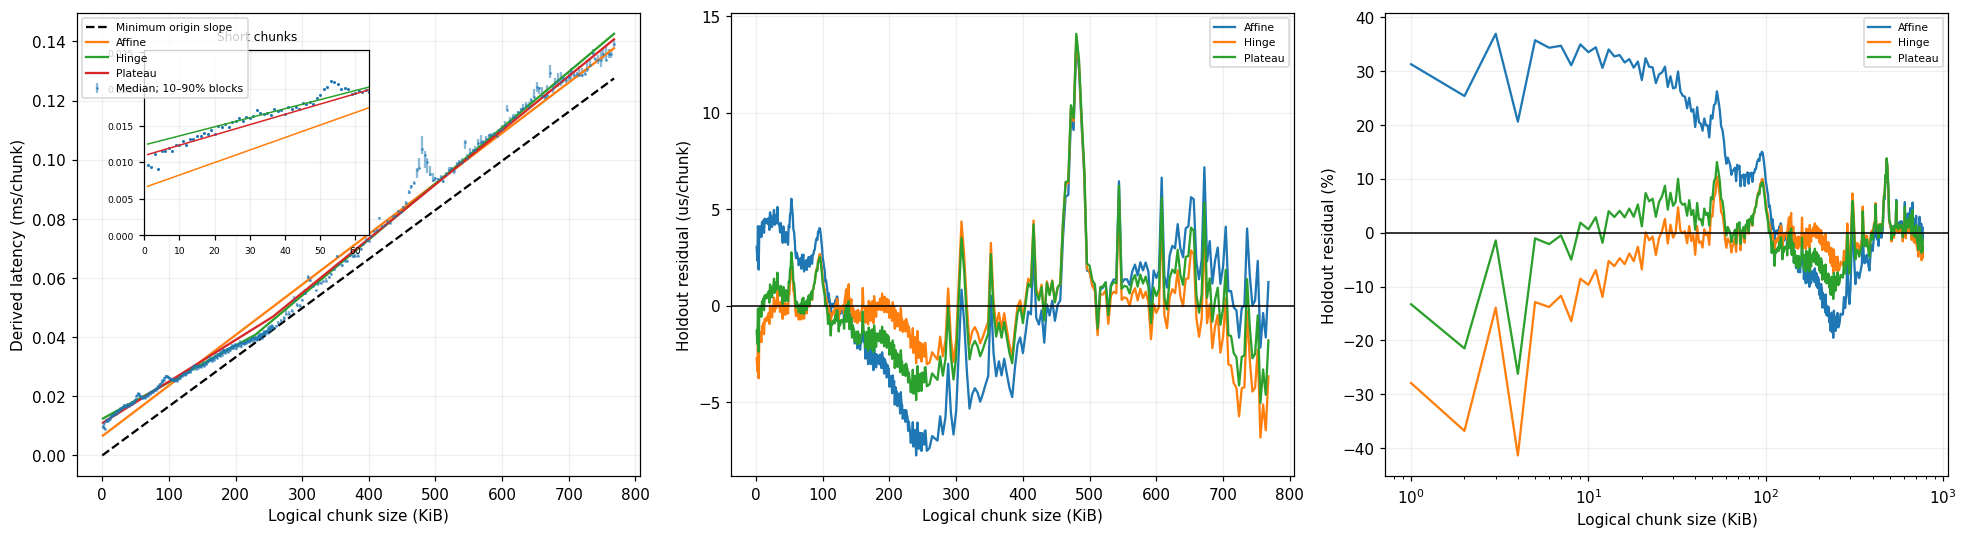

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].errorbar(x, y, yerr=[y - lo, hi - y], fmt=".", ms=2, alpha=.5, label="Median; 10–90% blocks")
axes[0].plot([0, x[-1]], [0, ratio.min() * x[-1]], "k--", label="Minimum origin slope")
zoom = axes[0].inset_axes([.12, .52, .4, .4])
zoom.plot(x, y, ".", ms=2)
for kind, prediction in models.items():
    axes[0].plot(x, prediction, label=kind)
    zoom.plot(x, prediction, lw=1)
    axes[1].plot(x, 1000 * (holdout - prediction), label=kind)
    axes[2].plot(x, 100 * (holdout - prediction) / holdout, label=kind)
zoom.set(xlim=(0, 64), ylim=(0, max(y[x <= 64]) * 1.2), title="Short chunks")
zoom.tick_params(labelsize=6)
zoom.title.set_fontsize(8)
axes[0].set(ylabel="Derived latency (ms/chunk)")
axes[1].set(ylabel="Holdout residual (us/chunk)")
axes[2].set(ylabel="Holdout residual (%)", xscale="log")
for ax in axes:
    ax.set_xlabel("Logical chunk size (KiB)")
    ax.legend(fontsize=7)
for ax in axes[1:]:
    ax.axhline(0, color="black", lw=1)
figure(RUN, "latency_models_holdout")

## 5. 기준 $s$와 다른 진단값을 구별

측정한 집합 $\mathcal G$에서만
$$s_{\min}=\arg\min_{x\in\mathcal G}\hat\rho(x),\qquad
s_{.05}=\min\{x:\hat\rho(x)\le1.05\hat\rho_{\min}\}.$$

기준 $s$는 **평활화 throughput의 99% 첫 도달점**이다. 위의 $s_{\min}$과 $s_{.05}$는 평활화하지 않은 전체 7개 블록의 $T(x)/x$에서 계산하는 별도 진단값이다. Hinge의 breakpoint도 latency 적합으로 고르는 별도 값이다. 이들이 같은 위치일 필요는 없다. 최소값 동률이면 가장 작은 크기를 선택한다.

포화 가설이 맞으려면 holdout에서도 $x\ge s$의 $T(x)/x$가 모델의 상수 기울기와 부합해야 한다. 아래 표는 이 구간의 상대오차와 경험적 near-best 이후 이탈 비율을 보여준다. 자동 합격 판정은 하지 않는다. 상한의 throughput peak, 경계 최소점, hinge 탐색 경계, 큰 잔차는 특히 주의해서 해석한다.

saturation_99pct_kib                     256.0
saturation_99pct_bits                  2097152
all_blocks_saturation_99pct_kib          256.0
hinge_breakpoint_kib                     230.0
argmin_kib                               240.0
near_best_5pct_kib                       220.0
minimum_at_upper_boundary                False
throughput_peak_at_upper_boundary        False
saturation_at_upper_boundary             False
near_best_later_outside_pct          75.757576
plateau_tail_holdout_mape_pct         2.718861
plateau_tail_points                        129
dtype: object

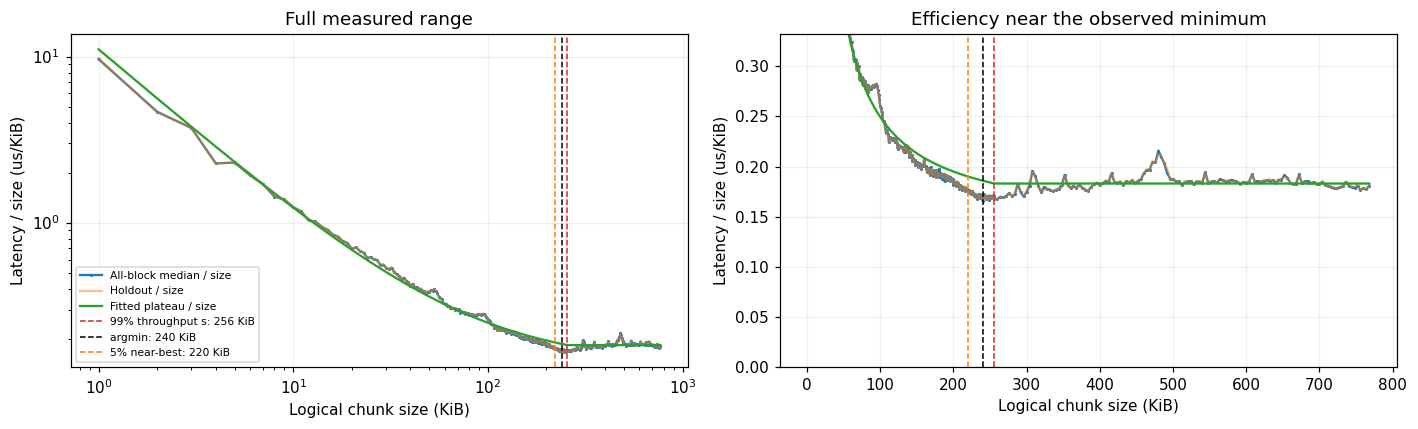

In [13]:
EPSILON = .05
s_min = float(x[np.argmin(ratio)])
s_near = float(x[np.flatnonzero(ratio <= (1 + EPSILON) * ratio.min())[0]])
tail = x >= s
plateau_slope = sum(parameters["Plateau"]["coefficients"])
holdout_ratio = holdout / x
selection = dict(saturation_99pct_kib=s, saturation_99pct_bits=int(s * 8192),
    all_blocks_saturation_99pct_kib=s_all, hinge_breakpoint_kib=parameters["Hinge"]["s_kib"],
    argmin_kib=s_min, near_best_5pct_kib=s_near,
    minimum_at_upper_boundary=bool(s_min == x[-1]),
    throughput_peak_at_upper_boundary=bool(x[train_smooth.argmax()] == x[-1]),
    saturation_at_upper_boundary=bool(s == x[-1]),
    near_best_later_outside_pct=float(100 * np.mean(ratio[x >= s_near] > 1.05 * ratio.min())),
    plateau_tail_holdout_mape_pct=float(100 * np.mean(np.abs(holdout_ratio[tail] - plateau_slope) / holdout_ratio[tail])),
    plateau_tail_points=int(tail.sum()))
display(pd.Series(selection))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax in axes:
    ax.plot(x, ratio * 1000, ".-", ms=2, label="All-block median / size")
    ax.plot(x, holdout_ratio * 1000, alpha=.5, label="Holdout / size")
    ax.plot(x, models["Plateau"] / x * 1000, label="Fitted plateau / size")
    for point, label, color in [(s, "99% throughput s", "tab:red"),
                                 (s_min, "argmin", "black"),
                                 (s_near, "5% near-best", "tab:orange")]:
        ax.axvline(point, ls="--", color=color, lw=1, label=f"{label}: {point:g} KiB")
    ax.set(xlabel="Logical chunk size (KiB)", ylabel="Latency / size (us/KiB)")
axes[0].set(xscale="log", yscale="log", title="Full measured range")
axes[1].set(ylim=(0, ratio.min() * 1000 * 2), title="Efficiency near the observed minimum")
axes[0].legend(fontsize=7)
figure(RUN, "efficiency_and_breakpoints")

## 6. 반복 블록 bootstrap

7개 블록을 복원추출할 때 **모든 크기에 동일한 블록 index**를 적용하고 median과 99% throughput 첫 도달점, 효율 최소점, 5% near-best를 다시 계산한다. 한 크기의 작은 오차막대는 여러 후보 중 선택한 최소점의 확실성을 뜻하지 않는다. 아래 5–95% 분위수는 이 격자와 7개 블록에 조건부인 선택 분포 요약이며, 물리적 포화점의 확정적 신뢰구간은 아니다. Plateau의 계수나 hinge breakpoint의 불확실성은 여기서 계산하지 않는다.

,saturation_99pct_kib,argmin_kib,near_best_kib
0.05,239.0,232.0,216.0
0.50,255.0,240.0,220.0
0.95,256.0,248.0,224.0


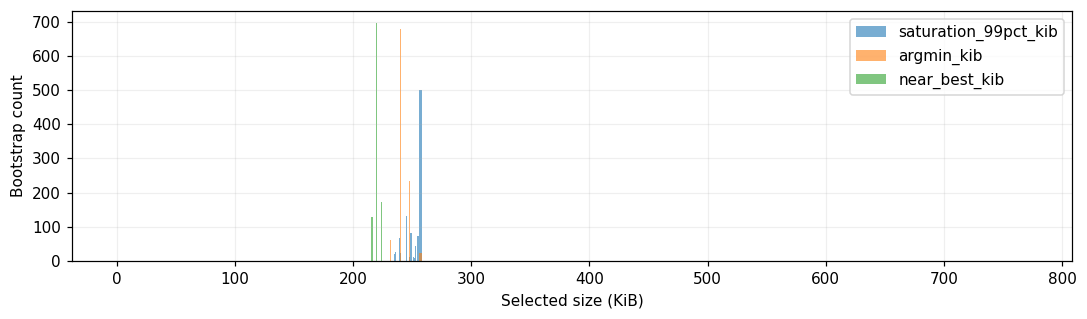

In [14]:
boot_rng = np.random.default_rng(SEED + 1)
bootstrap = []
for _ in range(1000):
    sampled = samples[:, boot_rng.integers(0, BLOCKS, BLOCKS)]
    median_ms = np.median(sampled, axis=1)
    rho = median_ms / x
    boot_s = throughput_threshold(median_ms)[0]
    bootstrap.append([boot_s, x[rho.argmin()], x[np.flatnonzero(rho <= 1.05 * rho.min())[0]]])
boot_frame = pd.DataFrame(bootstrap, columns=["saturation_99pct_kib", "argmin_kib", "near_best_kib"])
boot_frame.to_csv(RUN / "bootstrap_selections.csv", index=False)
display(boot_frame.quantile([.05, .5, .95]))
fig, ax = plt.subplots(figsize=(10, 3))
edges = np.r_[x[0] - .5, (x[:-1] + x[1:]) / 2, x[-1] + (x[-1] - x[-2]) / 2]
for column in boot_frame:
    ax.hist(boot_frame[column], bins=edges, alpha=.6, label=column)
ax.set(xlabel="Selected size (KiB)", ylabel="Bootstrap count")
ax.legend()
figure(RUN, "bootstrap_selection")

## 7. chunk 수에 따른 throughput 수렴 여부

서브모듈의 latency 추정은 충분한 총 I/O에서 throughput이 안정된다는 전제가 있다. 아래 왼쪽은 대표 크기에서 총 논리 읽기량 $qx$를 늘린 곡선이다. 모든 크기의 $(x,q,b)$ 요약도 CSV에 남긴다. 오른쪽은 각 크기에서 **실제로 측정한 마지막 두 $q$** 사이의 throughput 변화이며 7개 블록의 median과 10–90% 범위를 표시한다. 이는 원문의 $q=32\to64$ 검사보다 native sweep에 맞춘 진단이다.

마지막 두 점의 변화가 작다는 사실만으로 plateau를 증명할 수는 없다. $q$ 전체 곡선, 블록 변동, 큰 크기에서 줄어든 최대 $q$를 함께 확인해야 한다. chunk 수 sweep의 수렴과 chunk 크기에 대한 $T_S$ 가설은 서로 다른 조건이다.

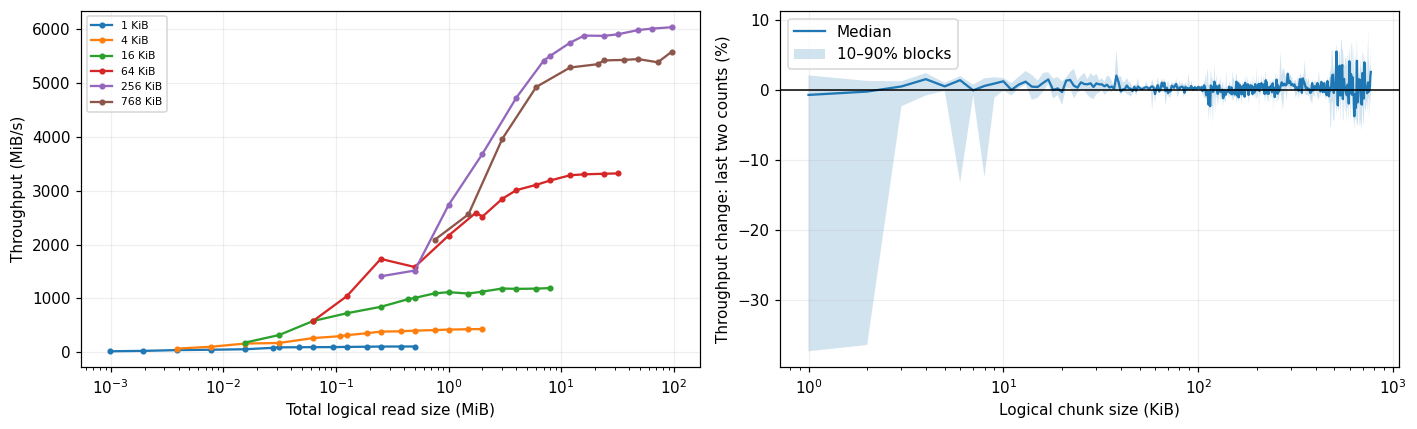

,previous_count,final_count,change_pct
size_kib,,,
1,384.0,512.0,-0.720722
2,384.0,512.0,-0.243886
3,384.0,512.0,0.490187
4,384.0,512.0,1.527944
5,384.0,512.0,0.500622
...,...,...,...
752,96.0,128.0,-0.225219
756,96.0,128.0,0.051751
760,96.0,128.0,0.446648


In [15]:
count_curve = raw.groupby(["size_kib", "block", "count"], as_index=False).io_us.median()
count_curve["total_mib"] = count_curve.size_kib * count_curve["count"] / 1024
count_curve["throughput_mib_s"] = count_curve.total_mib / (count_curve.io_us / 1e6)
count_curve.to_csv(RUN / "count_throughput.csv", index=False)
tail_rows = []
for (kib, block), group in count_curve.groupby(["size_kib", "block"]):
    last = group.sort_values("count").tail(2)
    previous, final = last.iloc[0], last.iloc[1]
    tail_rows.append(dict(size_kib=kib, block=block, previous_count=int(previous["count"]),
        final_count=int(final["count"]),
        change_pct=100 * (final.throughput_mib_s / previous.throughput_mib_s - 1)))
batch_change = pd.DataFrame(tail_rows)
batch_change.to_csv(RUN / "tail_count_change.csv", index=False)
change = batch_change.pivot(index="size_kib", columns="block", values="change_pct")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for kib in [1, 4, 16, 64, 256, 768]:
    group = count_curve[count_curve.size_kib == kib].groupby("count")
    points = group[["total_mib", "throughput_mib_s"]].median()
    axes[0].plot(points.total_mib, points.throughput_mib_s, ".-", label=f"{kib} KiB")
axes[0].set(xscale="log", xlabel="Total logical read size (MiB)", ylabel="Throughput (MiB/s)")
axes[0].legend(fontsize=7)
axes[1].plot(change.index, change.median(axis=1), label="Median")
axes[1].fill_between(change.index, change.quantile(.1, axis=1), change.quantile(.9, axis=1),
                     alpha=.2, label="10–90% blocks")
axes[1].axhline(0, color="black", lw=1)
axes[1].set(xscale="log", xlabel="Logical chunk size (KiB)", ylabel="Throughput change: last two counts (%)")
axes[1].legend()
figure(RUN, "count_convergence")
display(batch_change.groupby("size_kib")[["previous_count", "final_count", "change_pct"]].median())

## 8. 결과 요약과 해석

1. holdout RMSE·상대오차·잔차를 함께 비교한다. Plateau가 다른 모델보다 부적합하면 포화 두 직선 가설을 채택할 근거가 부족하다. 오차가 비슷하다면 유일한 형태가 식별되었다고 단정하지 않는다.
2. Plateau가 잘 맞더라도 이후 모든 길이가 같은 효율인 모델이다. throughput 기준 $s$와 유일한 물리적 최적 길이를 동일시하지 않는다. $d\approx0$이면 두 직선의 변화가 약하다는 단서다.
3. throughput peak 또는 첫 99% 도달점이 측정 상한에 붙거나 bootstrap 선택 분포가 넓으면 현재 범위로 포화 위치를 확정하지 않는다. 상한을 포화점으로 대입하거나 측정 밖으로 외삽하지 않는다.
4. chunk 수 sweep이 수렴하지 않으면 throughput 기반 latency 추정 자체의 한계도 함께 보고한다. 이번 결과는 이 장치·native reader·worker 수·논리 요청 단위에 한정된다. 다른 행 크기에서는 $s_{rows}=s_{bytes}/bytes_{row}$로 환산하고, 모델 채널과의 대응을 별도로 확인해야 한다.

원시 CSV, 설정, 적합 계수, holdout 비교와 그림은 고정 결과 폴더에 남긴다. 다른 노트북은 이 결과를 입력으로 재사용하지 않는다.

In [16]:
finish(RUN, **selection,
       best_holdout_model=fits.holdout_rmse_us.idxmin(),
       model_parameters=parameters,
       bootstrap_90pct=boot_frame.quantile([.05, .95]).to_dict(),
       median_abs_tail_count_change_pct=float(batch_change.change_pct.abs().median()),
       scope="Finite 1–768 KiB grid; native 6-worker throughput-derived latency; no automatic plateau claim")

**실행에서 확인한 값**

- **saturation_99pct_kib**: 256.0

- **saturation_99pct_bits**: 2097152

- **all_blocks_saturation_99pct_kib**: 256.0

- **hinge_breakpoint_kib**: 230.0

- **argmin_kib**: 240.0

- **near_best_5pct_kib**: 220.0

- **minimum_at_upper_boundary**: False

- **throughput_peak_at_upper_boundary**: False

- **saturation_at_upper_boundary**: False

- **near_best_later_outside_pct**: 75.75757575757575

- **plateau_tail_holdout_mape_pct**: 2.7188608843576443

- **plateau_tail_points**: 129

- **best_holdout_model**: Hinge

- **model_parameters**: {'Affine': {'s_kib': None, 'coefficients': [0.006532970548386405, 0.00017079809938813352]}, 'Hinge': {'s_kib': 230.0, 'coefficients': [0.012350397279148726, 0.0001239148280611668, 6.519697071364594e-05]}, 'Plateau': {'s_kib': 256.0, 'coefficients': [0.00014063365391609503, 4.260782180355241e-05]}}

- **bootstrap_90pct**: {'saturation_99pct_kib': {0.05: 239.0, 0.95: 256.0}, 'argmin_kib': {0.05: 232.0, 0.95: 248.0}, 'near_best_kib': {0.05: 216.0, 0.95: 224.0}}

- **median_abs_tail_count_change_pct**: 0.7885331472101464

- **scope**: Finite 1–768 KiB grid; native 6-worker throughput-derived latency; no automatic plateau claim